In [97]:
import numpy as np
import matplotlib.pyplot as plt
from PriceSim import stock_full_GBM, stock_full_jump_diff




import numpy as np
import matplotlib.pyplot as plt

#random values in N(0,1):
rng = np.random.default_rng(seed=42)



def stock_full_jump_diff(S_0,r, D,sigma,dt,T,lam,muj, delta, euler = False):
    steps = int(T/dt)+1 #Quantity of timesteps

    Z = rng.standard_normal(steps) #Random numbers generating 
    N = rng.poisson(lam*dt, steps) #Poisson random numbers

    kapa = np.exp(muj + 0.5*delta**2) - 1 #Correction term
    price = np.zeros(steps) #price array
    price[0] = S_0

    if euler == False:
        for j in range(steps-1): #price generation, we make a note that we do not simply generate the r.v. at each step, 
            # we pregenerate the random numbers before hand since it is more computationally efficient that way.
            #Additionally, we don't bother pregenerating the jump distribution because they happen rarely enough.
            jump_Z = rng.standard_normal(N[j]) #Random numbers generating for jumps 
            Y = np.exp(muj + delta*jump_Z) #Jump sizes
            price[j+1] = price[j] * np.exp((r - D - 0.5*sigma**2 - lam * kapa)*dt + sigma*np.sqrt(dt)*Z[j])*np.prod(Y)
    else: #We consider a computationally simpler method (Euler)
        for j in range(steps-1):
            jump_Z = rng.standard_normal(N[j]) #Random numbers generating for jumps
            Y = np.exp(muj + delta*jump_Z) #Jump sizes
            price[j+1] = price[j] * (1 + (r - D - lam * kapa) * dt + sigma * np.sqrt(dt) * Z[j] + np.sum(Y - 1))

    return price
    

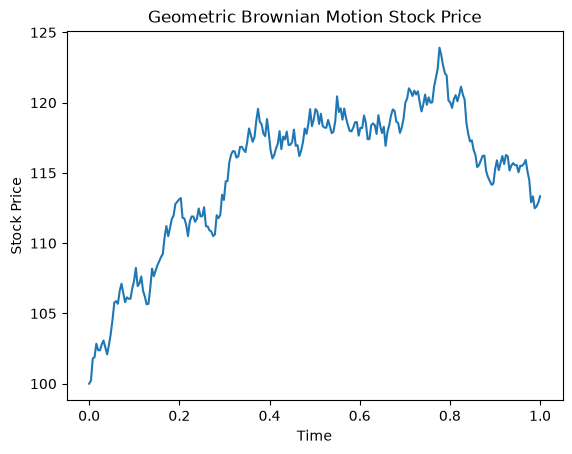

In [98]:
##Example of use: GBM

##Starting Conditions
t_arr, dt = np.linspace(0,1,252, retstep = True)
init_price = 100
D = 0.00
r = 0.05
Vol = 0.1
price = np.zeros(len(t_arr))

##stock_full
plt.plot(t_arr,stock_full_GBM(init_price,r,D,Vol,dt,1))
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Geometric Brownian Motion Stock Price")
plt.show()

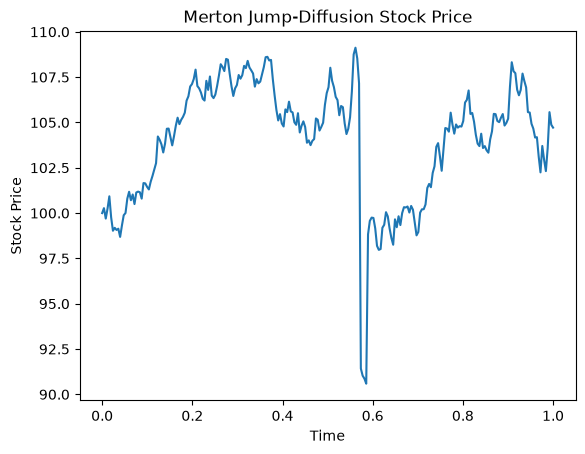

In [99]:
#Example of use: Merton Jump Diffusion Model

## Example of use: Merton Jump-Diffusion

## Starting Conditions
t_arr, dt = np.linspace(0, 1, 252, retstep=True)

init_price = 100
r = 0.05
D = 0.00
Vol = 0.10

lam = 2.0       # jump intensity
muj = -0.10     # mean log jump size
delta = 0.20    # volatility of log jump size

price = np.zeros(len(t_arr))

## stock_full_jump_diff
price = stock_full_jump_diff(
    init_price,
    r,
    D,
    Vol,
    dt,
    1,
    lam,
    muj,
    delta,
    True
)

plt.plot(t_arr, price)
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Merton Jump-Diffusion Stock Price")
plt.show()